# Employee Attrition Prediction

Predicting which employees might leave the company

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## Load Data

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Explore Data

In [3]:
df.info()
print("\nMissing values:", df.isnull().sum().sum())
print("\nAttrition distribution:")
print(df['Attrition'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

## Visualizations

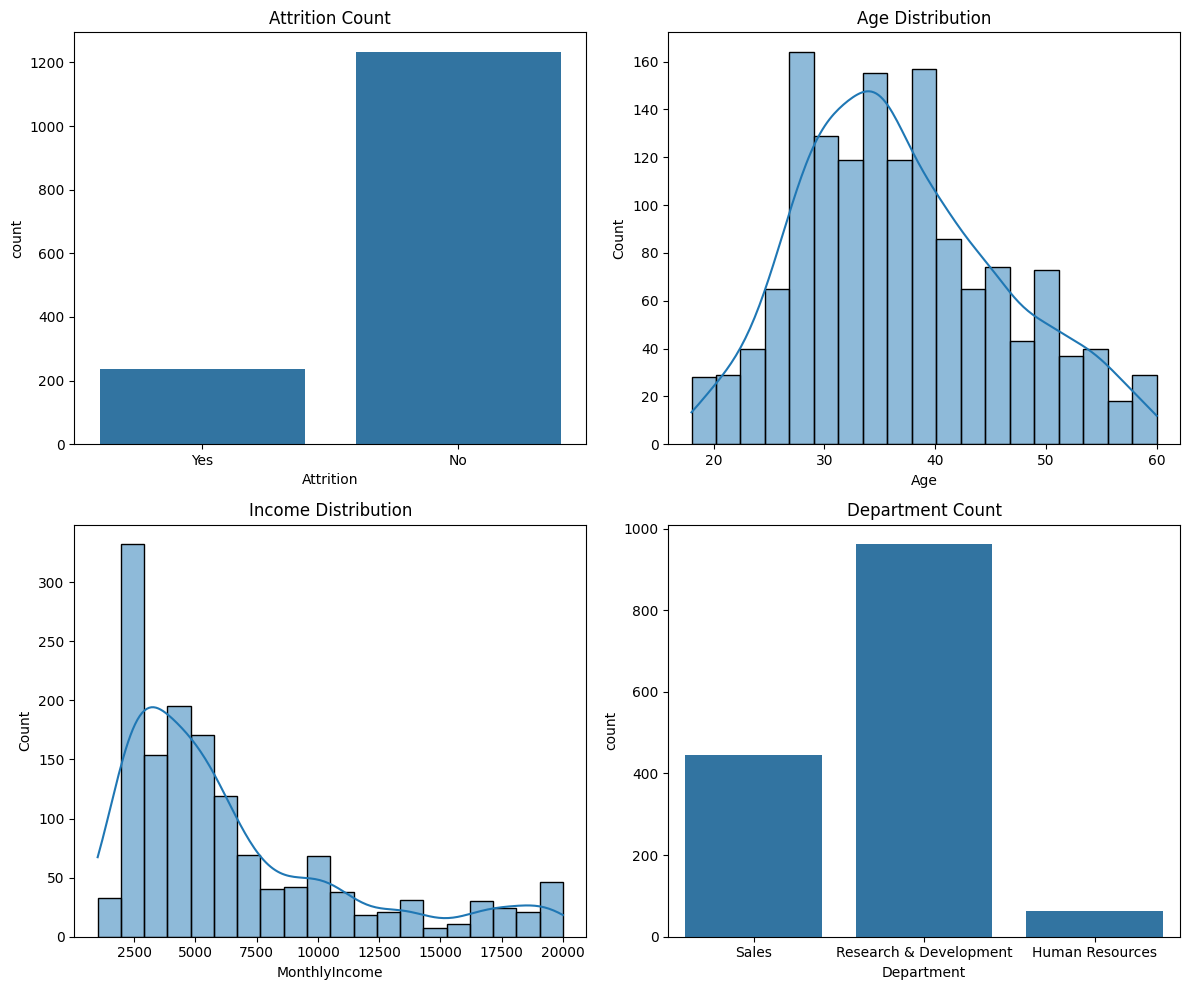

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(x='Attrition', data=df, ax=axes[0,0])
axes[0,0].set_title('Attrition Count')

sns.histplot(df['Age'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Age Distribution')

sns.histplot(df['MonthlyIncome'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Income Distribution')

sns.countplot(x='Department', data=df, ax=axes[1,1])
axes[1,1].set_title('Department Count')

plt.tight_layout()
plt.show()

## Data Preparation

In [5]:
df_processed = df.copy()

# Convert target to numeric
df_processed['Attrition'] = df_processed['Attrition'].map({'No': 0, 'Yes': 1})

# Encode categorical columns
categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])

# Drop unnecessary columns
df_processed = df_processed.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)

X = df_processed.drop('Attrition', axis=1)
y = df_processed['Attrition']

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (1470, 30)
Target: (1470,)


## Train Test Split & Scaling

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")

Train: (1176, 30)
Test: (294, 30)


## Train and Compare Models

In [7]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'SVM (RBF)': SVC(random_state=42, probability=True, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

results = []
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
print("\nModel comparison results:")
print(results_df)

best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]
print(f"\nBest model selected by F1 Score: {best_model_name}")

Training Logistic Regression...
Training Decision Tree...
Training SVM (RBF)...
Training Random Forest...
Training Gradient Boosting...

Model comparison results:
                 Model  Accuracy  Precision    Recall  F1 Score
0            SVM (RBF)  0.809524   0.430769  0.595745  0.500000
1  Logistic Regression  0.751701   0.367347  0.765957  0.496552
2        Decision Tree  0.758503   0.269231  0.297872  0.282828
3    Gradient Boosting  0.840136   0.500000  0.191489  0.276923
4        Random Forest  0.836735   0.444444  0.085106  0.142857

Best model selected by F1 Score: SVM (RBF)


## Evaluate Model

Best model selected: SVM (RBF)

Accuracy: 0.8095
Precision: 0.4308
Recall: 0.5957
F1 Score: 0.5000

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.92      0.85      0.88       247
   Attrition       0.43      0.60      0.50        47

    accuracy                           0.81       294
   macro avg       0.67      0.72      0.69       294
weighted avg       0.84      0.81      0.82       294



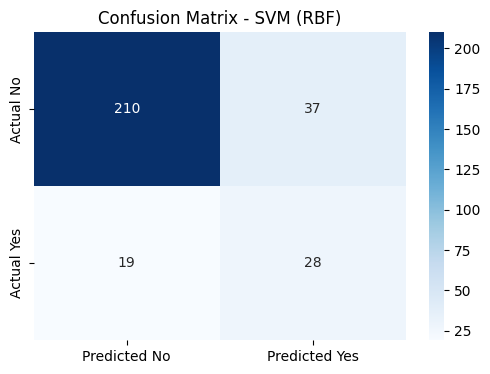

In [8]:
print(f"Best model selected: {best_model_name}\n")

best_y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, best_y_pred)
precision = precision_score(y_test, best_y_pred)
recall = recall_score(y_test, best_y_pred)
f1 = f1_score(y_test, best_y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, best_y_pred, target_names=['No Attrition', 'Attrition']))

cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No', 'Predicted Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [9]:
# Save the final trained model pipeline for the submission package
import joblib
from sklearn.pipeline import Pipeline

pipeline = Pipeline([('scaler', scaler), ('svm', best_model)])
joblib.dump(pipeline, 'model.pkl')
print('Saved final model pipeline to model.pkl')

Saved final model pipeline to model.pkl


## Feature Importance

<Figure size 1000x600 with 0 Axes>

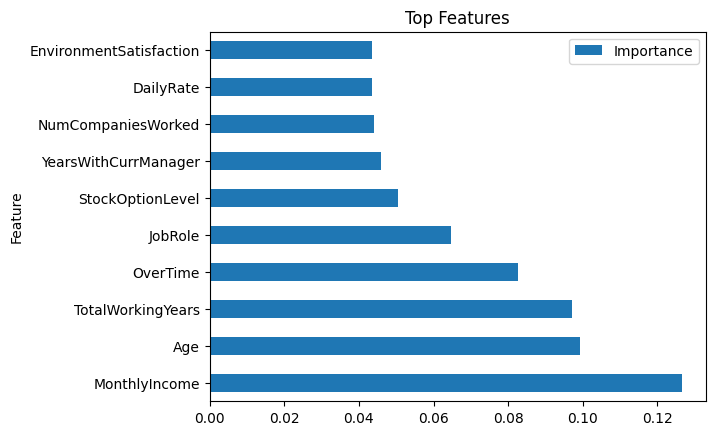

                    Feature  Importance
15            MonthlyIncome    0.126575
0                       Age    0.099159
23        TotalWorkingYears    0.096958
18                 OverTime    0.082687
12                  JobRole    0.064778
22         StockOptionLevel    0.050344
29     YearsWithCurrManager    0.045808
17       NumCompaniesWorked    0.044143
2                 DailyRate    0.043630
7   EnvironmentSatisfaction    0.043501


In [10]:
if hasattr(model, 'feature_importances_'):
    feature_imp = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
else:
    feature_imp = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': model.coef_[0]
    }).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plot_col = 'Importance' if 'Importance' in feature_imp.columns else 'Coefficient'
feature_imp.head(10).plot(x='Feature', y=plot_col, kind='barh')
plt.title('Top Features')
plt.show()

print(feature_imp.head(10))
